config.json:   0%|          | 0.00/578 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/286M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/286M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-small
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
mask_predictions.dense.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 01 | Loss: 0.7180
  Task 1 (Emotional) -> F1: 0.1098 | Acc (Exact): 0.3074
  Task 2 (IPV)       -> F1: 0.8116 | Acc        : 0.7842
  Sigmas -> T1: -0.001, T2: -0.003

Epoch 02 | Loss: 0.5230
  Task 1 (Emotional) -> F1: 0.1402 | Acc (Exact): 0.6225
  Task 2 (IPV)       -> F1: 0.9013 | Acc        : 0.9046
  Sigmas -> T1: -0.003, T2: -0.006

Epoch 03 | Loss: 0.4895
  Task 1 (Emotional) -> F1: 0.1562 | Acc (Exact): 0.6774
  Task 2 (IPV)       -> F1: 0.8992 | Acc        : 0.9004
  Sigmas -> T1: -0.004, T2: -0.009

Epoch 04 | Loss: 0.4339
  Task 1 (Emotional) -> F1: 0.1727 | Acc (Exact): 0.6327
  Task 2 (IPV)       -> F1: 0.9091 | Acc        : 0.9129
  Sigmas -> T1: -0.006, T2: -0.012

Epoch 05 | Loss: 0.4121
  Task 1 (Emotional) -> F1: 0.1766 | Acc (Exact): 0.6657
  Task 2 (IPV)       -> F1: 0.9185 | Acc        : 0.9212
  Sigmas -> T1: -0.007, T2: -0.015

Epoch 06 | Loss: 0.3777
  Task 1 (Emotional) -> F1: 0.1879 | Acc (Exact): 0.6501
  Task 2 (IPV)       -> F1: 0.9060 | Acc        :

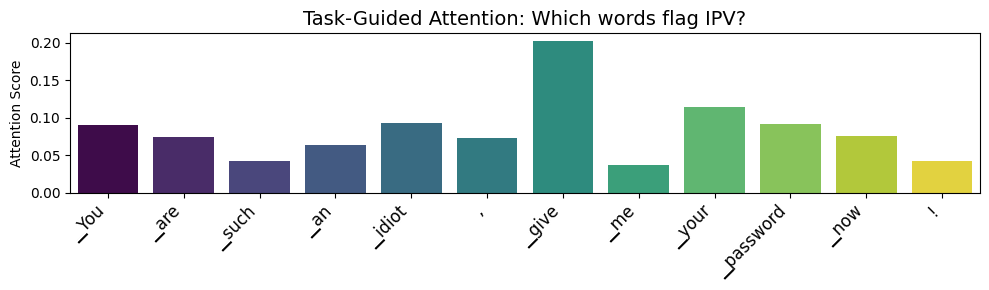

In [ ]:
import os

import pandas as pd
import numpy as np
import shelve
import torch
import torch.nn as nn
import random
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report, accuracy_score
from transformers import AutoTokenizer, AutoModel
from torch.utils.data import Dataset, DataLoader
from itertools import cycle

# 1. DATA LOADING & PREPROCESSING 
train_data = "/kaggle/input/datasets/shivamkc3/ucc-unhealthy-comments/train.csv"
val_data = "/kaggle/input/datasets/shivamkc3/ucc-unhealthy-comments/val.csv"
test_data = "/kaggle/input/datasets/shivamkc3/ucc-unhealthy-comments/test.csv"

task1_train_df = pd.read_csv(train_data).dropna(subset=["comment"])
task1_val_df = pd.read_csv(val_data).dropna(subset=["comment"])
task1_test_df = pd.read_csv(test_data).dropna(subset=["comment"])

LABEL_COLS = ["hostile", "antagonize", "dismissive", "condescending", "sarcastic"]
TEXT_COL = "comment"

def build_task1_df(df):
    return pd.DataFrame({
        "text": df[TEXT_COL].tolist(),                 
        "labels_task1": df[LABEL_COLS].values.tolist(),
        "labels_task2": None,
        "task": 1
    })

task1_train_df = build_task1_df(task1_train_df)
task1_val_df = build_task1_df(task1_val_df)
task1_test_df = build_task1_df(task1_test_df)

# Load Task 2 Data
path = "/kaggle/input/datasets/ihsna20/redditdata-abusedata/reddit_data/redditAbuseOnlyNgrams"
db = shelve.open(path, flag='r')
X_train_2 = db["XTrain"]
y_train_2 = db["labelsTrain"]
db.close()

y_train_2 = [1 if x == "abuse" else 0 for x in y_train_2]

X_train_2, X_val_2, y_train_2, y_val_2 = train_test_split(
    X_train_2, y_train_2, test_size=0.1, stratify=y_train_2, random_state=42
)

task2_train_df = pd.DataFrame({"text": X_train_2, "labels_task2": y_train_2, "labels_task1": None, "task": 2})
task2_val_df = pd.DataFrame({"text": X_val_2, "labels_task2": y_val_2, "labels_task1": None, "task": 2})

# 2. DATASETS & DATALOADERS
tokenizer = AutoTokenizer.from_pretrained("microsoft/deberta-v3-small")
MAX_LEN = 128

class MTL_Dataset(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        enc = tokenizer(row["text"], truncation=True, max_length=MAX_LEN)
        item = {"input_ids": enc["input_ids"], "attention_mask": enc["attention_mask"], "task": row["task"]}
        if row["task"] == 1: item["labels_task1"] = row["labels_task1"]
        else: item["labels_task2"] = row["labels_task2"]
        return item

def mtl_collate_fn(batch):
    input_ids = [torch.tensor(item["input_ids"]) for item in batch]
    attention_mask = [torch.tensor(item["attention_mask"]) for item in batch]
    
    input_ids = torch.nn.utils.rnn.pad_sequence(input_ids, batch_first=True, padding_value=tokenizer.pad_token_id)
    attention_mask = torch.nn.utils.rnn.pad_sequence(attention_mask, batch_first=True, padding_value=0)
    
    tasks = [item["task"] for item in batch]
    batch_dict = {"input_ids": input_ids, "attention_mask": attention_mask, "task": torch.tensor(tasks)}
    
    task1_labels = [item.get("labels_task1", None) for item in batch]
    task2_labels = [item.get("labels_task2", None) for item in batch]
    if task1_labels[0] is not None: batch_dict["labels_task1"] = torch.tensor(task1_labels, dtype=torch.float)
    if task2_labels[0] is not None: batch_dict["labels_task2"] = torch.tensor(task2_labels, dtype=torch.float)
    return batch_dict

BATCH_SIZE = 8
task1_train_loader = DataLoader(MTL_Dataset(task1_train_df), batch_size=BATCH_SIZE, shuffle=True, collate_fn=mtl_collate_fn)
task1_val_loader   = DataLoader(MTL_Dataset(task1_val_df), batch_size=BATCH_SIZE, collate_fn=mtl_collate_fn)
task1_test_loader  = DataLoader(MTL_Dataset(task1_test_df), batch_size=BATCH_SIZE, collate_fn=mtl_collate_fn)
task2_train_loader = DataLoader(MTL_Dataset(task2_train_df), batch_size=BATCH_SIZE, shuffle=True, collate_fn=mtl_collate_fn)
task2_val_loader   = DataLoader(MTL_Dataset(task2_val_df), batch_size=BATCH_SIZE, collate_fn=mtl_collate_fn)


# NOVELTY 1: Task-Guided Hierarchical Attention Architecture
class TaskGuidedAttentionMTL(nn.Module):
    def __init__(self, model_name="microsoft/deberta-v3-small", mode="full"):
        super().__init__()
        
        self.mode = mode 

        self.encoder = AutoModel.from_pretrained(model_name)
        hidden_size = self.encoder.config.hidden_size

        for param in self.encoder.parameters():
            param.requires_grad = False

        for layer in self.encoder.encoder.layer[-2:]:
            for param in layer.parameters():
                param.requires_grad = True

        self.t1_feature_extractor = nn.Sequential(
            nn.Dropout(0.1),
            nn.Linear(hidden_size, hidden_size),
            nn.LayerNorm(hidden_size),
            nn.ReLU()
        )
        self.t1_classifier = nn.Linear(hidden_size, 5)

        self.t2_cross_attn = nn.MultiheadAttention(
            embed_dim=hidden_size,
            num_heads=4,
            dropout=0.1,
            batch_first=True
        )

        self.t2_classifier = nn.Sequential(
            nn.Linear(hidden_size * 2, 64), 
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(64, 1)
        )

        self.log_sigma1 = nn.Parameter(torch.zeros(1))
        self.log_sigma2 = nn.Parameter(torch.zeros(1))

    def forward(self, input_ids, attention_mask, return_attention=False):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        sequence_output = outputs.last_hidden_state

        input_mask_expanded = attention_mask.unsqueeze(-1).expand(sequence_output.size()).float()
        mean_pooled = torch.sum(sequence_output * input_mask_expanded, 1) / torch.clamp(input_mask_expanded.sum(1), min=1e-9)

        t1_features = self.t1_feature_extractor(mean_pooled)
        t1_logits = self.t1_classifier(t1_features)

        if self.mode == "no_t1":
            Q = mean_pooled.unsqueeze(1)
        elif self.mode == "shuffle_t1":
            shuffled = t1_features[torch.randperm(t1_features.size(0))]
            Q = shuffled.unsqueeze(1)
        elif self.mode == "zero_t1":
            Q = torch.zeros_like(t1_features).unsqueeze(1)
        else:  # "full"
            Q = t1_features.unsqueeze(1)

        K = V = sequence_output
        padding_mask = (attention_mask == 0)

        t2_attended, attn_weights = self.t2_cross_attn(
            Q, K, V, key_padding_mask=padding_mask
        )

        t2_attended = t2_attended.squeeze(1)

        combined = torch.cat([t2_attended, mean_pooled], dim=1)

        t2_logits = self.t2_classifier(combined)

        if return_attention:
            return t1_logits, t2_logits, attn_weights

        return t1_logits, t2_logits

# 3. LOSS FUNCTIONS & SETUP
class FocalLoss(nn.Module):
    def __init__(self, gamma=2, pos_weight=None):
        super().__init__()
        self.gamma = gamma
        self.pos_weight = pos_weight

    def forward(self, logits, targets):
        bce = nn.functional.binary_cross_entropy_with_logits(logits, targets, reduction='none', pos_weight=self.pos_weight)
        pt = torch.exp(-bce)
        loss = ((1 - pt) ** self.gamma) * bce
        return loss.mean()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = TaskGuidedAttentionMTL(mode="full").to(device)
model = model.float()
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)

labels = np.array(task1_train_df["labels_task1"].tolist())
pos_counts = labels.sum(axis=0)
neg_counts = len(labels) - pos_counts
pos_weight = torch.tensor(neg_counts / (pos_counts + 1e-5), dtype=torch.float32).to(device)

loss1_fn = FocalLoss(gamma=2, pos_weight=pos_weight)
loss2_fn = nn.BCEWithLogitsLoss()

# 4. TRAINING LOOP 
EPOCHS = 50 
ACCUMULATION_STEPS = 4
STEPS_PER_EPOCH = 500

best_val_f1 = 0
best_thresholds = [0.5] * 5

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    t1_iter = iter(task1_train_loader)
    t2_iter = cycle(task2_train_loader)
    optimizer.zero_grad()

    for step in range(STEPS_PER_EPOCH):
        try: batch1 = next(t1_iter)
        except StopIteration:
            t1_iter = iter(task1_train_loader)
            batch1 = next(t1_iter)
        batch2 = next(t2_iter)

        batch1 = {k: v.to(device) for k, v in batch1.items() if torch.is_tensor(v)}
        batch2 = {k: v.to(device) for k, v in batch2.items() if torch.is_tensor(v)}

        # Standard FP32 Training
        t1_out, _ = model(batch1["input_ids"], batch1["attention_mask"])
        _, t2_out = model(batch2["input_ids"], batch2["attention_mask"])

        l1 = loss1_fn(t1_out, batch1["labels_task1"])
        l2 = loss2_fn(t2_out, batch2["labels_task2"].unsqueeze(1))

        loss = (0.5 * torch.exp(-model.log_sigma1) * l1 + 0.5 * model.log_sigma1 + 
                0.5 * torch.exp(-model.log_sigma2) * l2 + 0.5 * model.log_sigma2) / ACCUMULATION_STEPS

        loss.backward()
        
        if (step + 1) % ACCUMULATION_STEPS == 0:
            optimizer.step()
            optimizer.zero_grad()
            
        total_loss += loss.item() * ACCUMULATION_STEPS

    # Validation 
    model.eval()
    
    # 1. Evaluate Task 1
    val_logits_all = []
    val_labels_all = []
    with torch.no_grad():
        for batch1 in task1_val_loader:
            batch1 = {k: v.to(device) for k, v in batch1.items() if torch.is_tensor(v)}
            t1_out, _ = model(batch1["input_ids"], batch1["attention_mask"])
            
            val_logits_all.append(t1_out.cpu())
            val_labels_all.extend(batch1["labels_task1"].cpu().numpy())

    # 2. Evaluate Task 2
    val_t2_preds = []
    val_t2_labels = []
    with torch.no_grad():
        for batch2 in task2_val_loader:
            batch2 = {k: v.to(device) for k, v in batch2.items() if torch.is_tensor(v)}
            _, t2_out = model(batch2["input_ids"], batch2["attention_mask"])
            
            val_t2_preds.extend((torch.sigmoid(t2_out).squeeze(-1) > 0.5).int().cpu().numpy())
            val_t2_labels.extend(batch2["labels_task2"].cpu().numpy())

    # Metrics Calculation
    val_logits_all = torch.cat(val_logits_all, dim=0)
    val_labels_np = np.array(val_labels_all)
    probs_all = torch.sigmoid(val_logits_all).numpy()
    
    best_thresholds = []
    for i in range(probs_all.shape[1]):
        best_t, best_f1_t1 = 0.5, 0
        for t in np.arange(0.1, 0.9, 0.05):
            preds = (probs_all[:, i] > t).astype(int)
            f1 = f1_score(val_labels_np[:, i], preds, zero_division=0)
            if f1 > best_f1_t1:
                best_f1_t1 = f1
                best_t = t
        best_thresholds.append(best_t)

    final_preds_t1 = (probs_all > np.array(best_thresholds)).astype(int)
    
    # Calculate F1 and Accuracy
    val_f1_t1 = f1_score(val_labels_np, final_preds_t1, average="macro", zero_division=0)
    val_acc_t1 = accuracy_score(val_labels_np, final_preds_t1) # Exact Match Subset Accuracy
    
    val_f1_t2 = f1_score(val_t2_labels, val_t2_preds, zero_division=0)
    val_acc_t2 = accuracy_score(val_t2_labels, val_t2_preds)

    # Save Best Model
    if val_f1_t1 > best_val_f1:
        best_val_f1 = val_f1_t1
        torch.save(model.state_dict(), "best_model.pt")
        
    print(f"Epoch {epoch+1:02d} | Loss: {total_loss/STEPS_PER_EPOCH:.4f}")
    print(f"  Task 1 (Emotional) -> F1: {val_f1_t1:.4f} | Acc (Exact): {val_acc_t1:.4f}")
    print(f"  Task 2 (IPV)       -> F1: {val_f1_t2:.4f} | Acc        : {val_acc_t2:.4f}")
    print(f"  Sigmas -> T1: {model.log_sigma1.item():.3f}, T2: {model.log_sigma2.item():.3f}\n")


# 5. ABLATION STUDY 
print("\n" + "="*50)
print("RUNNING ABLATION STUDY")
print("="*50)

# Load the best weights
model.load_state_dict(torch.load("best_model.pt"))
model.eval()

ablation_modes = ["full", "no_t1", "shuffle_t1", "zero_t1"]

for mode in ablation_modes:
    model.mode = mode # Set the current ablation mode
    val_t2_preds = []
    val_t2_labels = []
    
    with torch.no_grad():
        for batch2 in task2_val_loader:
            batch2 = {k: v.to(device) for k, v in batch2.items() if torch.is_tensor(v)}
            _, t2_out = model(batch2["input_ids"], batch2["attention_mask"])
            
            val_t2_preds.extend((torch.sigmoid(t2_out).squeeze(-1) > 0.5).int().cpu().numpy())
            val_t2_labels.extend(batch2["labels_task2"].cpu().numpy())
            
    f1 = f1_score(val_t2_labels, val_t2_preds, zero_division=0)
    acc = accuracy_score(val_t2_labels, val_t2_preds)
    print(f"Mode: {mode.ljust(12)} | Task 2 F1: {f1:.4f} | Task 2 Acc: {acc:.4f}")

# 6. VISUALIZATION
print("\n" + "="*50)
print("GENERATING ATTENTION VISUALIZATION")
print("="*50)

def visualize_hierarchical_attention(text):
    model.mode = "full" # Ensure model is back to normal mode before visualizing
    model.eval()
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)
    if "token_type_ids" in inputs: inputs.pop("token_type_ids")
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        t1_out, t2_out, attn_weights = model(inputs["input_ids"], inputs["attention_mask"], return_attention=True)

    scores = attn_weights[0, 0, :].cpu().numpy()
    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
    
    valid_idx = [i for i, t in enumerate(tokens) if t != tokenizer.pad_token]
    tokens = [tokens[i] for i in valid_idx]
    scores = [scores[i] for i in valid_idx]

    plt.figure(figsize=(10, 3))
    sns.barplot(x=list(range(len(tokens))), y=scores, palette="viridis", hue=list(range(len(tokens))), legend=False)
    plt.xticks(range(len(tokens)), tokens, rotation=45, ha='right', fontsize=12)
    plt.title("Task-Guided Attention: Which words flag IPV?", fontsize=14)
    plt.ylabel("Attention Score")
    plt.tight_layout()
    plt.show()

visualize_hierarchical_attention("You are such an idiot, give me your password now!")